# 5. Yeast display: chymotrypsin selection

This notebook demonstrates the use of clibas to analyze yeast display library selections using data from Angelini and co-workers as an example. We will try to reproduce their results, which can be found in [S. Linciano _et al_. Screening macrocyclic peptide libraries by yeast display allows control of selection process and affinity ranking. _Nat. Commun._ **2025**, 16, 5367](https://www.nature.com/articles/s41467-025-60907-x)

The authors conducted affinity selection of mono- and bicyclic peptides against five structurally diverse targets using yeast surface display. For this example, we will analyze only the selection against α-chymotrypsin, which is denoted as PT5 in the paper. 

Disulfide bond formation was used to achieve peptide macrocyclization using the standard genetic code (no genetic code reprogramming). The peptide library was constructed by mixing 5 sub-libraries each containing peptides with either 2 or 3 fixed cysteine residues in a 9-15-residue insert. The 3-Cys peptides may bear an extra Cys in the random insert, and therefore will form bicyclic disulfide-bonded structures. 

NGS data was provided in a single-end read `.fastq` format, and the reads look like this:

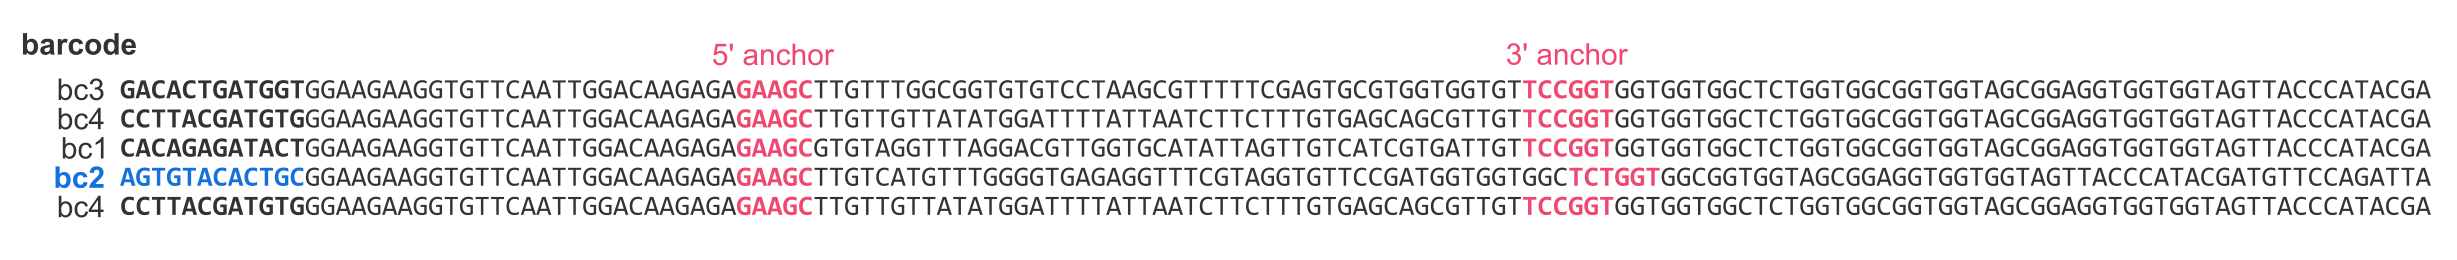

Reads are barcoded by 12-nt barcodes at the 5'-end; there are 5 barcodes in total, and the PT5-derived library is barcoded by `bc2` (highlighted in blue in the figure above). It's not clear what other barcodes represent, but this is not important for us here. 

The ORF of interest is flanked by a longer constant DNA region that is also not important for our purposes. In the paper, the authors report trimming the reads to the 5- and 6-nt anchor sequences highlighted in red in the figure above prior to conducting downstream analysis. The enclosed region encodes the variable region sequence as well as a few constant region amino acids (`EAC` at the N-terminal side, and `CSG` at the C-terminal side). We can process the reads similarly, and write the library designs accordingly:

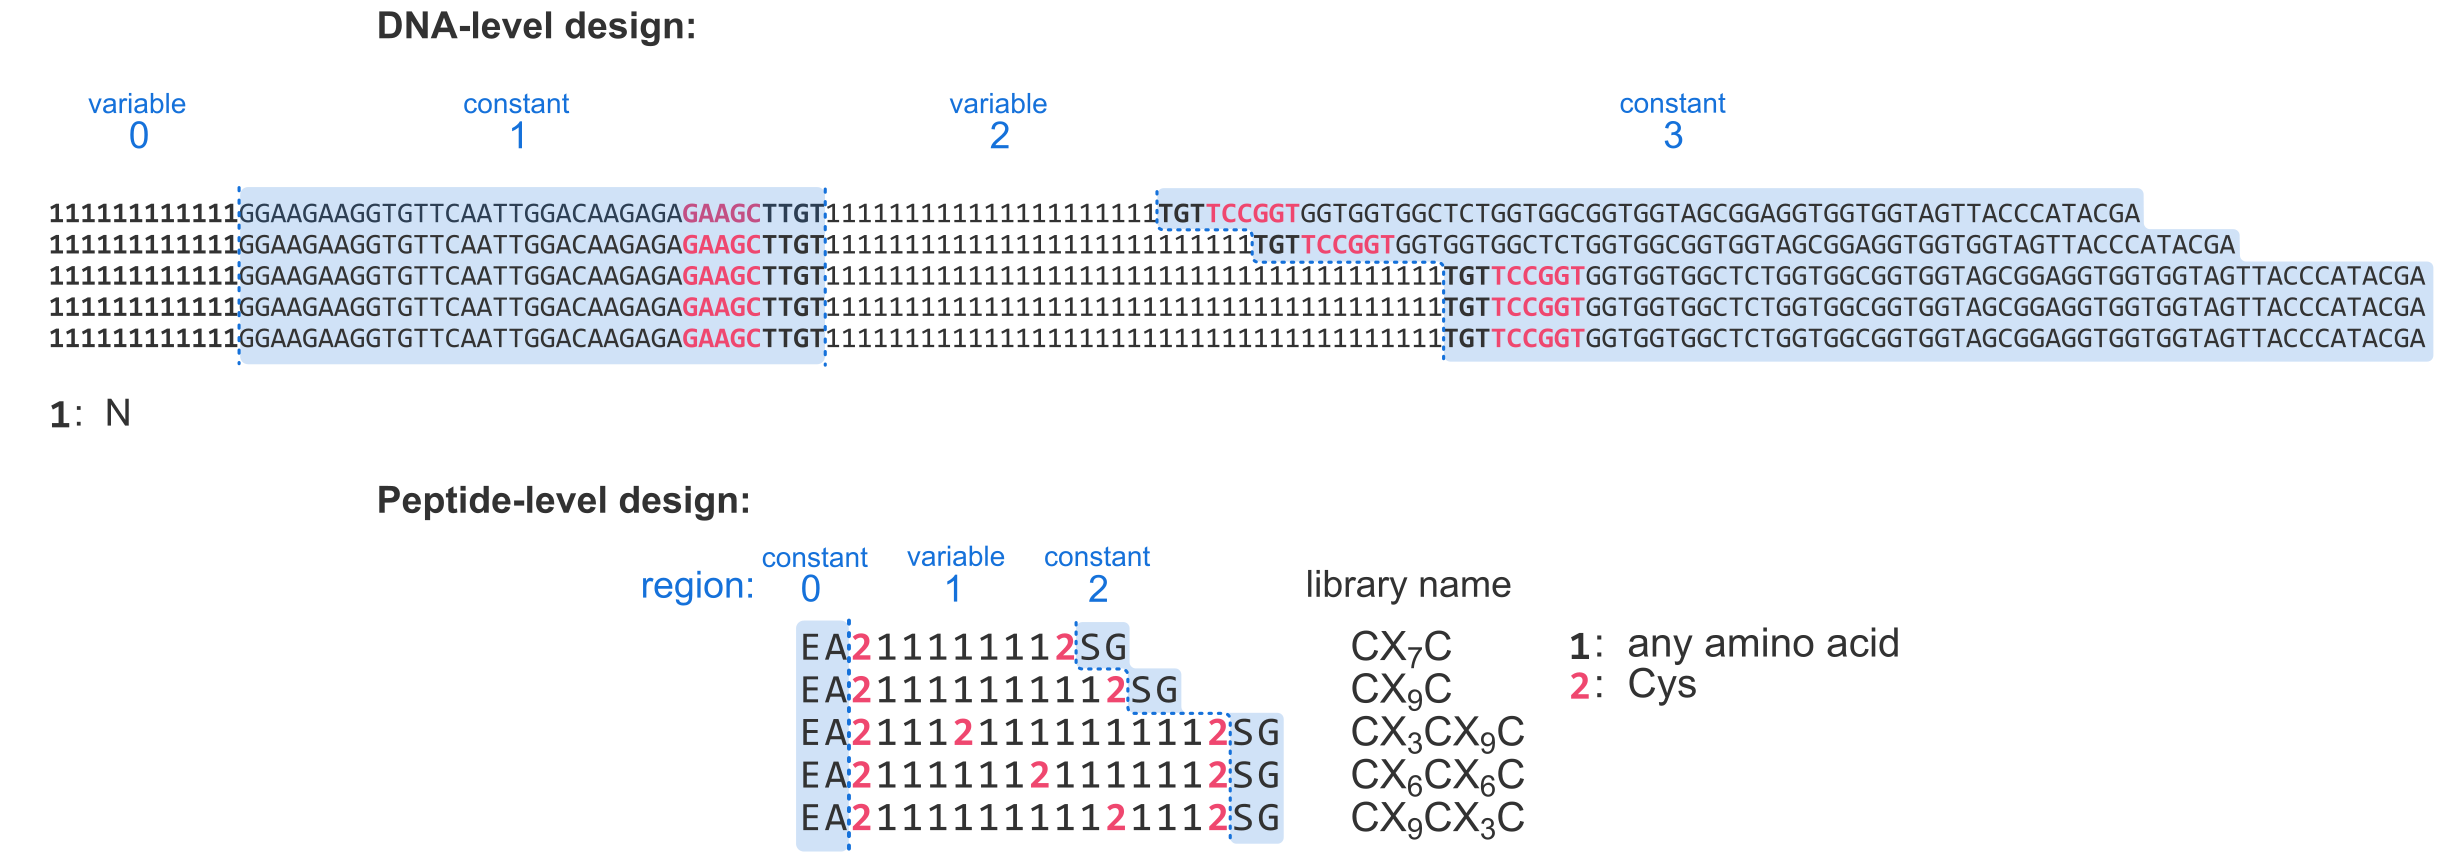

The corresponding config file then looks like this:

```yaml
experiment: "Angelini_yeast_selections"

LibraryDesigns:
  dna_templates:
    - "111111111111GGAAGAAGGTGTTCAATTGGACAAGAGAGAAGCTTGT111111111111111111111TGTTCCGGTGGTGGTGGCTCTGGTGGCGGTGGTAGCGGAGGTGGTGGTAGTTACCCATACGA"
    - "111111111111GGAAGAAGGTGTTCAATTGGACAAGAGAGAAGCTTGT111111111111111111111111111TGTTCCGGTGGTGGTGGCTCTGGTGGCGGTGGTAGCGGAGGTGGTGGTAGTTACCCATACGA"
    - "111111111111GGAAGAAGGTGTTCAATTGGACAAGAGAGAAGCTTGT111111111111111111111111111111111111111TGTTCCGGTGGTGGTGGCTCTGGTGGCGGTGGTAGCGGAGGTGGTGGTAGTTACCCATACGA"
    - "111111111111GGAAGAAGGTGTTCAATTGGACAAGAGAGAAGCTTGT111111111111111111111111111111111111111TGTTCCGGTGGTGGTGGCTCTGGTGGCGGTGGTAGCGGAGGTGGTGGTAGTTACCCATACGA"
    - "111111111111GGAAGAAGGTGTTCAATTGGACAAGAGAGAAGCTTGT111111111111111111111111111111111111111TGTTCCGGTGGTGGTGGCTCTGGTGGCGGTGGTAGCGGAGGTGGTGGTAGTTACCCATACGA"
        
  dna_monomers:
    1: ["A", "G", "T", "C"] #N

  pep_templates:
    - "E3211111112SG"
    - "E321111111112SG"
    - "E3211121111111112SG"
    - "E3211111121111112SG"
    - "E3211111111121112SG"
 
  pep_monomers:
    1: ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    2: ["C"]
    3: ["A"]

FastqParserConfig:
  sample_barcodes:
    bc1: "CACAGAGATACT"
    bc2: "AGTGTACACTGC"  
    bc3: "GACACTGATGGT"  
    bc4: "CCTTACGATGTG"  
    bc5: "TCTGAGGATCCA"  

TrackerConfig:
  logs: "./outputs/Angelini_yeast_v2"                 # Directory for writing logs to
  parser_out: "./outputs/Angelini_yeast_v2"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Angelini_yeast_v2"         # Directory that stores outputs of data analysis operations
  
LoggerConfig:
  verbose: true                     # Verbose loggers print to the console
  log_to_file: true                 # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"
```

The key feature of this config is the FastqParserConfig element that holds the barcode information:

```yaml
FastqParserConfig:
  sample_barcodes:
    bc1: "CACAGAGATACT"
    bc2: "AGTGTACACTGC"  
    bc3: "GACACTGATGGT"  
    bc4: "CCTTACGATGTG"  
    bc5: "TCTGAGGATCCA"  
```

We will just try to reproduce the original paper without doing any additional analyses – refer to earlier examples for this. 
clibas provides a function called `C.fastq_parser.demultiplex_sample_barcodes` which allows us to split a `.fastq` file into several sub-samples by their respective barcodes. This operation takes `barcode_loc` as a keyword: it points to a region in a DNA library design that encodes the barcode. For this reason, we indicate the first 12-nt as a standalone variable region in the designs above: so that we can point to it to match the barcodes as `barcode_loc=[0]`. This operation has to be called before read trimming, because the barcode information will be lost after that point. 

Next, to (roughly) reproduce the original paper, we trim the reads, do their Q-score filtering (in the paper, reads containing Q scores below 18 are discarded), and run in silico translation. Trimmed reads don't have a start codon, so we have to "force" translation to start. Because the trimming is done in-frame with the ORF, we can set `force_at_frame=0` for `C.fastq_parser.translate` operation.

After, peptide products are filtered by length: only the ORFs between 11- and 19-residues-long are retained in the paper. Here, we can just call `C.fastq_parser.len_filter(where='pep')` to discard all translation products that do not comply with our design specifications. 

Finally, just like in the paper, we clip peptide sequences to regions 0 and 1 (effectively removing the C-terminal `SG`), and count them, writing the outputs to a `.csv` file.

The entire pipeline is ~12 lines of code:

In [1]:
import clibas as C
C.initialize(config_path='Angelini_yeast_config.yaml')

C.pipeline.enque(
    
[
    C.fastq_parser.demultiplex_sample_barcodes(barcode_loc=[0], barcode_tol=0),
    C.fastq_parser.trim_reads(left='GAAGC', right='TCCGGT', tol=0), 
    C.fastq_parser.q_score_filt(minQ=18, loc=None),
    C.fastq_parser.translate(force_at_frame=0, stop_readthrough=False),
    C.fastq_parser.len_filter(where='pep'),
    C.fastq_parser.fetch_at(where='pep', loc=[0, 1]),
    C.fastq_parser.count_summary(where='pep', top_n=None, fmt='csv'),
]
)

loader = C.data_loader.fetch_fastq_from_dir(data_dir='./sequencing_data/Angelini_yeast/PT5')
data = C.pipeline.load_and_run(loader=loader, save_summary=True)

[INFO]: <clibas> succesfully loaded config and is ready. . .
[INFO]: 7 ops appended to pipeline; current queue size: 7
[INFO]: Queuing <fetch_dir_fastq> op. . .
[INFO]: Fetching Angelini_Yeast_PT5.fastq. . .
[INFO]: The operation took 1.178 s
[INFO]: Angelini_Yeast_PT5 dataset size: 723231
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <split_by_barcode> op. . .
[INFO]: The operation took 4.656 s
[INFO]: Angelini_Yeast_PT5_bc1 dataset size: 139216
[INFO]: Angelini_Yeast_PT5_bc2 dataset size: 101324
[INFO]: Angelini_Yeast_PT5_bc3 dataset size: 170597
[INFO]: Angelini_Yeast_PT5_bc4 dataset size: 182184
[INFO]: Angelini_Yeast_PT5_bc5 dataset size: 112118
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <trim_exp> op. . .
[INFO]: The operation took 1.374 s
[INFO]: Angelini_Yeast_PT5_bc1 dataset size: 139216
[INFO]: Angelini_Yeast_PT5_bc2 dataset size: 101324
[INFO]: Angelini_Yeast_PT5_bc3 dataset size: 1705

Let's load the resulting peptide count files and compare:

In [6]:
from pathlib import Path
import pandas as pd

out_dir = C.fastq_parser.dirs.logs
sample_name = "Angelini_Yeast_PT5_bc2"
out_dir = Path(out_dir) / sample_name

fname = next(Path(out_dir).glob(f"{sample_name}_pep_count_summary*.csv"))
df = pd.read_csv(fname)
df.head(20).style.set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,Index,Peptide,DNA,pep count,Dataset %
0,1,EACRDWTWIQC,GAAGCTTGTCGTGATTGGACTTGGATTCAGTGTTCCGGT,10119,24.211609
1,2,EACRDWTWVSC,GAAGCTTGTAGGGATTGGACGTGGGTTTCGTGTTCCGGT,7988,19.112791
2,3,EACHRWGVRFSLC,GAAGCTTGTCATCGTTGGGGGGTGAGGTTTTCGTTGTGTTCCGGT,2194,5.249557
3,4,EACLHVCLERGQCLFMC,GAAGCTTGTCTGCATGTGTGTTTGGAGCGTGGGCAGTGTCTGTTTATGTGTTCCGGT,1991,4.763842
4,5,EACRDWTWVAC,GAAGCTTGTCGTGATTGGACTTGGGTGGCGTGTTCCGGT,1977,4.730344
5,6,EACCYRIYCPC,GAAGCTTGTTGTTATAGGATTTATTGTCCGTGTTCCGGT,1564,3.742164
6,7,EACAWCLRGTICC,GAAGCTTGTGCTTGGTGTCTTAGGGGTACGATTTGTTGTTCCGGT,1302,3.115280
7,8,EACHSWFTRMSAC,GAAGCTTGTCATTCGTGGTTTACGAGGATGAGTGCTTGTTCCGGT,1114,2.665454
8,9,EACLYMCARTRPCNALC,GAAGCTTGTTTGTATATGTGTGCGCGTACTCGTCCGTGTAATGCGTTGTGTTCCGGT,1097,2.624779
9,10,EACAFCIGRPICC,GAAGCTTGTGCTTTTTGTATTGGTAGGCCTATTTGTTGTTCCGGT,1078,2.579318


These results are not identical, but are _very_ similar to what is reported in the paper; minor differences likely stem from the fact that filtering operation are not commutative, and a different _order_ of operations can lead to different outcomes. Either way, our results are qualititatively nearly identical. Compare:

In [10]:
#Translated_BC2 chemo_GOOD.txt is taken directly from Angelini and co-workers
paper_df = pd.read_csv('Translated_BC2 chemo_GOOD.txt', header=None, sep='\s+')
paper_df.head(20).style.set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,0,1,2
0,EACRDWTWIQC,10202,GAAGCTTGTCGTGATTGGACTTGGATTCAGTGTT
1,EACRDWTWVSC,8033,GAAGCTTGTAGGGATTGGACGTGGGTTTCGTGTT
2,EACHRWGVRFSLC,2229,GAAGCTTGTCATCGTTGGGGGGTGAGGTTTTCGTTGTGTT
3,EACRDWTWVAC,1999,GAAGCTTGTCGTGATTGGACTTGGGTGGCGTGTT
4,EACLHVCLERGQCLFMC,1977,GAAGCTTGTCTGCATGTGTGTTTGGAGCGTGGGCAGTGTCTGTTTATGTGTT
5,EACCYRIYCPC,1589,GAAGCTTGTTGTTATAGGATTTATTGTCCGTGTT
6,EACAWCLRGTICC,1317,GAAGCTTGTGCTTGGTGTCTTAGGGGTACGATTTGTTGTT
7,EACHSWFTRMSAC,1135,GAAGCTTGTCATTCGTGGTTTACGAGGATGAGTGCTTGTT
8,EACLYMCARTRPCNALC,1107,GAAGCTTGTTTGTATATGTGTGCGCGTACTCGTCCGTGTAATGCGTTGTGTT
9,EACAFCIGRPICC,1093,GAAGCTTGTGCTTTTTGTATTGGTAGGCCTATTTGTTGTT
